In [1]:
import numpy as np 
import pandas as pd
import gensim
import re
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [2]:
#preprocessing the dataset
def preprocess_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = text.split()
    return ' '.join(tokens)

df = pd.read_csv('dataset/Truth_Seeker_Model_Dataset.csv')
df = df[['tweet', 'BinaryNumTarget']].dropna()
df['BinaryNumTarget'] = df['BinaryNumTarget'].astype(int)

df = df.sample(n=10000, random_state=42).reset_index(drop=True)
df['preprocessed_tweet'] = df['tweet'].astype(str).apply(preprocess_text)

In [4]:
#loading and creating tweet embeddings through mean pooling
word2vector_model = api.load('word2vec-google-news-300')

def tweet_to_vector(tweet: str, model, dim: int = 300):
    tokens = tweet.split()
    vectors = []
    for token in tokens:
        if token in model.key_to_index:
            vectors.append(model[token])
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(dim)

X = []
for t in df['preprocessed_tweet']:
    vector = tweet_to_vector(t, word2vector_model, 300)
    X.append(vector)
X = np.vstack(X)
y = df['BinaryNumTarget'].values

oov_count = 0
for t in df['preprocessed_tweet']:
    tokens = t.split()
    tweet_with_known_word = False
    for token in tokens:
        if token in word2vector_model.key_to_index:
            tweet_with_known_word = True
            break
    if not tweet_with_known_word:
        oov_count = oov_count + oov_count

In [ ]:
#training the word2vector model and calculating the accuracy, precision, recall, f1 score and roc-auc values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_metrics = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': [],
    'roc_auc': [],
}

for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), start=1):
    X_cv_train, X_cv_val = X[train_idx], X[val_idx]
    y_cv_train, y_cv_val = y[train_idx], y[val_idx]

    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_cv_train, y_cv_train)

    val_pred = rf.predict(X_cv_val)
    val_prob = rf.predict_proba(X_cv_val)[:, 1]

    cv_metrics['accuracy'].append(accuracy_score(y_cv_val, val_pred))
    cv_metrics['precision'].append(precision_score(y_cv_val, val_pred, pos_label=1, zero_division=0))
    cv_metrics['recall'].append(recall_score(y_cv_val, val_pred, pos_label=1, zero_division=0))
    cv_metrics['f1_score'].append(f1_score(y_cv_val, val_pred, pos_label=1, zero_division=0))
    cv_metrics['roc_auc'].append(roc_auc_score(y_cv_val, val_prob))

    print(f'Fold {fold}  acc={cv_metrics["accuracy"][-1]:.4f}  '
          f'prec={cv_metrics["precision"][-1]:.4f}  '
          f'rec={cv_metrics["recall"][-1]:.4f}  '
          f'f1={cv_metrics["f1"][-1]:.4f}  '
          f'roc_auc={cv_metrics["roc_auc"][-1]:.4f}')

print('\nCross-Validation Summary')
for metric, scores in cv_metrics.items():
    print(f'{metric:12s}: {np.mean(scores):.4f} ± {np.std(scores):.4f}')

Fold 1  acc=0.8155  prec=0.8254  rec=0.8166  f1=0.8210  roc_auc=0.8976
Fold 2  acc=0.8170  prec=0.8197  rec=0.8292  f1=0.8244  roc_auc=0.8912
Fold 3  acc=0.8135  prec=0.8130  rec=0.8311  f1=0.8220  roc_auc=0.9008
Fold 4  acc=0.8410  prec=0.8533  rec=0.8369  f1=0.8450  roc_auc=0.9170
Fold 5  acc=0.8205  prec=0.8285  rec=0.8245  f1=0.8265  roc_auc=0.8992

Cross-Validation Summary
accuracy    : 0.8215 ± 0.0100
precision   : 0.8280 ± 0.0137
recall      : 0.8276 ± 0.0068
f1_score    : 0.8278 ± 0.0088
roc_auc     : 0.9011 ± 0.0086


In [21]:
#applying Random Forest classifier 
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

y_pred = rf_final.predict(X_test)
y_prob = rf_final.predict_proba(X_test)[:, 1]

test_acc  = accuracy_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
test_rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
test_f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
test_auc  = roc_auc_score(y_test, y_prob)

print(f'Accuracy: {test_acc:.4f}')
print(f'Precision: {test_prec:.4f}  (positive class = 1)')
print(f'Recall: {test_rec:.4f}  (positive class = 1)')
print(f'F1: {test_f1:.4f}  (positive class = 1)')
print(f'ROC-AUC: {test_auc:.4f}  (positive class = 1)')
print("\n")
print(classification_report(y_test, y_pred, target_names=['False (0)', 'True (1)']))

Accuracy: 0.8240
Precision: 0.8314  (positive class = 1)
Recall: 0.8282  (positive class = 1)
F1: 0.8298  (positive class = 1)
ROC-AUC: 0.8997  (positive class = 1)


              precision    recall  f1-score   support

   False (0)       0.82      0.82      0.82       964
    True (1)       0.83      0.83      0.83      1036

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



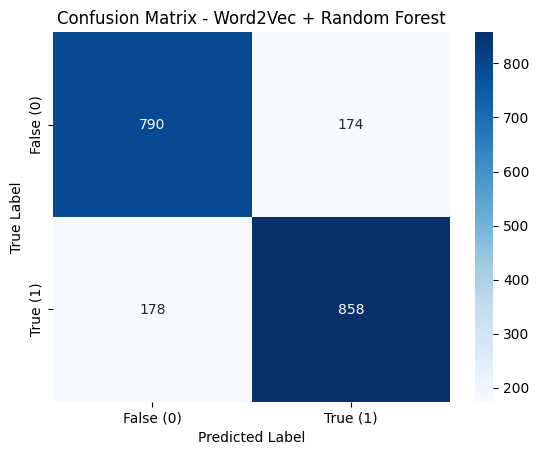

In [22]:
#create confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=["False (0)", "True (1)"], yticklabels=["False (0)", "True (1)"], cmap='Blues')
plt.title('Confusion Matrix - Word2Vec + Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()